# Proyecto ABP – Analítica de Datos
# **Nombre del Alumno: González Heredia Jessica Naomi**

SmartRetail: ¿Quién compra y cuánto ganamos?

**Metodología:** Aprendizaje Basado en Proyectos (ABP).  

**Objetivo:** Resolver un problema sencillo de negocio con datos **sintéticos generados aquí mismo**, aplicando:- Preprocesamiento básico-

**Clasificación** (¿compra / no compra?)-

**Regresión** (predecir utilidad) con **imputación de faltantes**---


In [ ]:
#Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, r2_score
np.random.seed(123)

## 1) Generar datos sintéticos

In [ ]:
#Dataset 1: Clientes y Compras (Clasificación)
n = 900
edad = np.random.randint(18, 70, size=n)
ingreso_mensual = np.clip(np.random.normal(22000, 7000, size=n), 5000, 60000)
frecuencia_visitas = np.clip(np.random.poisson(4, size=n), 0, 20)
historial_deuda = np.random.choice([0,1], size=n, p=[0.75, 0.25])
uso_cupones = np.random.choice([0,1], size=n, p=[0.5, 0.5])
nivel_educativo = np.random.choice(['Secundaria','Bachillerato','Licenciatura'], size=n, p=[0.3, 0.45, 0.25])
#Score simple (mayor ingreso, más visitas, uso de cupones, sin deuda -> mayor prob. compra)
score = 0.00006*ingreso_mensual + 0.25*frecuencia_visitas + 0.6*uso_cupones - 0.7*historial_deuda
prob = 1/(1+np.exp(-score))
compro = np.random.binomial(1, np.clip(prob, 0.05, 0.95))
df_clientes = pd.DataFrame({
    'edad': edad,
    'ingreso_mensual': ingreso_mensual.round(2),
    'frecuencia_visitas': frecuencia_visitas,
    'historial_deuda': historial_deuda,
    'uso_cupones': uso_cupones,
    'nivel_educativo': nivel_educativo,
    'compro': compro})
#Pequeños faltantes fáciles (3–4%)
for col in ['ingreso_mensual','frecuencia_visitas']:
  mask = np.random.rand(n) < 0.035
  df_clientes.loc[mask, col] = np.nan
print('Clientes & Compras listo.')
df_clientes.head()

Clientes & Compras listo.


,edad,ingreso_mensual,frecuencia_visitas,historial_deuda,uso_cupones,nivel_educativo,compro
0,69,29441.46,4.0,0,1,Bachillerato,1
1,34,11285.98,3.0,0,1,Bachillerato,0
2,36,21194.56,5.0,1,1,Licenciatura,1
3,36,24831.31,6.0,0,0,Bachillerato,1
4,28,26783.95,4.0,0,1,Licenciatura,1


In [ ]:
#Dataset 2: Finanzas Mensuales (Regresión, con faltantes)
m = 600

#Generación de variables predictoras
ventas_mes_anterior = np.clip(np.random.normal(180000, 35000, size=m), 60000, 400000)
gastos_operativos = np.clip(np.random.normal(110000, 25000, size=m), 30000, 220000)
clientes_nuevos   = np.clip(np.random.poisson(70, size=m), 5, 250)
campania_publicitaria = np.random.choice([0,1], size=m, p=[0.6, 0.4])
clima_economico   = np.random.uniform(0.4, 1.0, size=m)

#Componente de ruido
ruido = np.random.normal(0, 12000, size=m)

#Cálculo de la variable objetivo (Utilidad) - Corregido el espaciado
utilidad = (0.38 * ventas_mes_anterior - 0.33 * gastos_operativos + 180 * clientes_nuevos +
            12000 * campania_publicitaria + 25000 * clima_economico + ruido)

#Creación del DataFrame
df_finanzas = pd.DataFrame({
    'ventas_mes_anterior': ventas_mes_anterior.round(2),
    'gastos_operativos': gastos_operativos.round(2),
    'clientes_nuevos': clientes_nuevos,
    'campania_publicitaria': campania_publicitaria,
    'clima_economico': np.round(clima_economico, 3),
    'utilidad': np.round(utilidad, 2)
})

#Faltantes intencionales (~8-10%) SOLO en predictoras
for col in ['ventas_mes_anterior','gastos_operativos','clientes_nuevos']:
    mask = np.random.rand(m) < 0.09
    df_finanzas.loc[mask, col] = np.nan

print('Finanzas listo.')
print(df_finanzas.head())

Finanzas listo.
   ventas_mes_anterior  gastos_operativos  clientes_nuevos  \
0            218345.82           92306.59             79.0   
1            176618.28          118009.63             67.0   
2            182697.27                NaN             61.0   
3            202632.96          116069.59             64.0   
4            125532.28          141269.24              NaN   

   campania_publicitaria  clima_economico  utilidad  
0                      0            0.929  90422.76  
1                      0            0.638  71755.85  
2                      1            0.977  89168.13  
3                      0            0.554  54364.70  
4                      0            0.865  25999.72  


In [ ]:
# Guardar por si quieren exportar (opcional)
df_clientes.to_csv('clientes_compras.csv', index=False)
df_finanzas.to_csv('finanzas_mensuales.csv', index=False)

print('CSV guardados en el entorno.')

CSV guardados en el entorno.


## 2) Preprocesamiento simple (para ambos datasets)


In [ ]:
from IPython.display import display

print('--- Diagnóstico: df_clientes ---')
display(df_clientes.info())
# describe(include='all') es útil si hay columnas no numéricas (categoricas)
display(df_clientes.describe(include='all'))
print('\nFaltantes en df_clientes:')
display(df_clientes.isnull().sum())

print('\n' + '='*50 + '\n')

print('--- Diagnóstico: df_finanzas ---')
display(df_finanzas.info())
display(df_finanzas.describe(include='all'))
print('\nFaltantes en df_finanzas:')
display(df_finanzas.isnull().sum())

--- Diagnóstico: df_clientes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edad                900 non-null    int64  
 1   ingreso_mensual     877 non-null    float64
 2   frecuencia_visitas  873 non-null    float64
 3   historial_deuda     900 non-null    int64  
 4   uso_cupones         900 non-null    int64  
 5   nivel_educativo     900 non-null    object 
 6   compro              900 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 49.3+ KB


None

,edad,ingreso_mensual,frecuencia_visitas,historial_deuda,uso_cupones,nivel_educativo,compro
count,900.0000,877.000000,873.000000,900.000000,900.000000,900,900.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,Bachillerato,NaN
freq,NaN,NaN,NaN,NaN,NaN,412,NaN
mean,43.7200,22439.179749,4.014891,0.255556,0.518889,NaN,0.902222
std,14.6701,7391.710421,2.048384,0.436416,0.499921,NaN,0.297179
min,18.0000,5000.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,31.0000,17257.970000,3.000000,0.000000,0.000000,NaN,1.000000
50%,44.0000,22706.990000,4.000000,0.000000,1.000000,NaN,1.000000
75%,56.0000,27365.270000,5.000000,1.000000,1.000000,NaN,1.000000



Faltantes en df_clientes:


,0
edad,0
ingreso_mensual,23
frecuencia_visitas,27
historial_deuda,0
uso_cupones,0
nivel_educativo,0
compro,0




--- Diagnóstico: df_finanzas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ventas_mes_anterior    539 non-null    float64
 1   gastos_operativos      542 non-null    float64
 2   clientes_nuevos        530 non-null    float64
 3   campania_publicitaria  600 non-null    int64  
 4   clima_economico        600 non-null    float64
 5   utilidad               600 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 28.3 KB


None

,ventas_mes_anterior,gastos_operativos,clientes_nuevos,campania_publicitaria,clima_economico,utilidad
count,539.000000,542.000000,530.000000,600.000000,600.000000,600.000000
mean,177912.701447,109196.692546,70.798113,0.370000,0.692348,66677.200567
std,34928.516016,25442.570289,9.135340,0.483207,0.172927,22043.156725
min,70085.940000,37016.290000,42.000000,0.000000,0.401000,5184.690000
25%,153533.080000,92506.882500,65.000000,0.000000,0.542000,52201.440000
50%,179611.580000,109626.235000,70.000000,0.000000,0.690000,67931.220000
75%,201916.330000,127566.672500,77.000000,1.000000,0.832250,82327.932500
max,283607.910000,193700.650000,101.000000,1.000000,1.000000,148039.890000



Faltantes en df_finanzas:


,0
ventas_mes_anterior,61
gastos_operativos,58
clientes_nuevos,70
campania_publicitaria,0
clima_economico,0
utilidad,0


Observaciones del diagnóstico.

Dataset 1: df_clientes

- Las columnas con faltantes son:
ingreso_mensual y frecuencia_visitas (~3–4%).

- Las variables numéricas (edad, ingreso_mensual, frecuencia_visitas) necesitan escalamiento si se usan modelos sensibles a magnitudes.

- nivel_educativo es categórica → requiere codificación OneHotEncoder.

- historial_deuda y uso_cupones ya están en formato binario (0/1), no requieren codificación.

- La variable objetivo es compro (0/1) → problema de clasificación.

Dataset 2: df_finanzas

- Las columnas con faltantes son:
ventas_mes_anterior, gastos_operativos y clientes_nuevos (~8–10%).

- Todas las predictoras son numéricas, excepto campania_publicitaria (binaria 0/1).

- Las variables numéricas pueden beneficiarse de escalamiento antes de aplicar regresión.

- No se requieren codificaciones complejas, solo imputación numérica.

- La variable objetivo es utilidad, continua → problema de regresión.

Resumen del diagnóstico

- Ambos datasets presentan faltantes leves, fáciles de imputar con SimpleImputer.

- Un dataset mezcla variables numéricas + categóricas (df_clientes), mientras que el otro es casi totalmente numérico (df_finanzas).

- Para df_clientes: imputar + codificar + escalar.

- Para df_finanzas: imputar + escalar.

- Las salidas están listas para clasificación (compro) y regresión (utilidad).

## 3) Clasificación

In [ ]:
# --- Preparación ---
# Separar las variables predictoras (Xc) de la variable objetivo (yc)
Xc = df_clientes.drop('compro', axis=1)
yc = df_clientes['compro']

# Identificar columnas numéricas y categóricas
num_cols_c = Xc.select_dtypes(include=['float64','int64']).columns.tolist()
# Ajuste: Incluir 'object' (para nivel_educativo) y excluir las binarias si se quieren manejar separadas,
# pero aquí las binarias ya están en num_cols_c (int64), lo cual es correcto.
cat_cols_c = Xc.select_dtypes(include=['object','bool']).columns.tolist()

# 2. Definición del Preprocesador (Pipeline)
pre_c = ColumnTransformer([
    # Pipeline para variables NUMÉRICAS: Imputar faltantes con la mediana
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median'))
    ]), num_cols_c),

    # Pipeline para variables CATEGÓRICAS: Imputar faltantes con la moda y aplicar One-Hot Encoding
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols_c)
])

# 3. División del dataset en entrenamiento y prueba
# Se usa stratify=yc porque 'compro' es la variable objetivo de clasificación
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc,
    yc,
    test_size=0.3,
    random_state=42,
    stratify=yc
)

print('Listo: split clasificación.')
# El preprocesador (pre_c) aún no se ha ajustado, solo definido.

Listo: split clasificación.


### TODO 3 – Entrenar y evaluar el Árbol de Decisión1.

In [ ]:
# Entrenar y evaluar
# 1. Definir el Pipeline con el preprocesador (pre_c) y el modelo
clf = Pipeline([
    ('prep', pre_c),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# 2. Entrenar el Pipeline
clf.fit(Xc_train, yc_train)

# 3. Predecir en el conjunto de prueba
predc = clf.predict(Xc_test)

# 4. Calcular y reportar métricas
acc = accuracy_score(yc_test, predc)
cm = confusion_matrix(yc_test, predc)

print('Accuracy:', round(acc, 4))
print('Matriz de confusión:\n', cm)

Accuracy: 0.825
Matriz de confusión:
 [[  4  25]
 [ 17 194]]


2. Comentario de Razonabilidad.

El Accuracy del 82.5% sugiere un buen rendimiento general. Sin embargo, al examinar la Matriz de Confusión, observamos que el modelo es muy malo prediciendo la clase 0 (No Compra), con solo 4 predicciones correctas de un total de 4 + 25 = 29 casos reales. El modelo está fuertemente sesgado hacia predecir la clase 1 (Compra), lo cual podría indicar un problema de desbalance en los datos originales o que la profundidad del árbol (max_depth=5) no es suficiente para capturar las diferencias de la clase minoritaria.

## 4) Regresión – ¿Cuánta utilidad?


In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd # Asegúrate de que pandas esté importado si usas .copy() y .isnull().sum()

# Crear una copia de seguridad para trabajar
df_fin = df_finanzas.copy()

# Definir el imputador de mediana
imp_num = SimpleImputer(strategy='median')

# Aplicar el imputador a las columnas predictoras con faltantes
# 'utilidad' se deja sin tocar.
df_fin[['ventas_mes_anterior','gastos_operativos','clientes_nuevos']] = imp_num.fit_transform(
    df_fin[['ventas_mes_anterior','gastos_operativos','clientes_nuevos']]
)

print('Imputación terminada. Faltantes restantes por columna:\n', df_fin.isnull().sum())

Imputación terminada. Faltantes restantes por columna:
 ventas_mes_anterior      0
gastos_operativos        0
clientes_nuevos          0
campania_publicitaria    0
clima_economico          0
utilidad                 0
dtype: int64


### TODO 5 – Preparar X

In [ ]:
# 1. Definición de X, y
Xr = df_fin.drop('utilidad', axis=1) # Predictoras
yr = df_fin['utilidad']             # Objetivo

# 2. Identificación de columnas y Preprocesador
# Todas las columnas son numéricas y necesitan escalamiento
num_cols_r = Xr.columns.tolist()
pre_r = ColumnTransformer([
    # Pipeline para variables NUMÉRICAS: aplicar Estandarización
    ('num', Pipeline([
        ('sc', StandardScaler())
    ]), num_cols_r)
])

# 3. División del dataset en entrenamiento y prueba (train_test_split)
# Nota: Aquí usaste test_size=0.2, mientras que en el TODO 5 anterior usamos 0.3.
# Uso 0.2 para mantener consistencia con tu código.
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)


# 4. Regresión Lineal (Pipeline y Entrenamiento)
pipe_lr = Pipeline([
    ('prep', pre_r),
    ('lr', LinearRegression())
])
pipe_lr.fit(Xr_train, yr_train)
pred_lr = pipe_lr.predict(Xr_test)


# 5. Árbol de Regresión (Pipeline y Entrenamiento)
pipe_tr = Pipeline([
    ('prep', pre_r),
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42))
])
pipe_tr.fit(Xr_train, yr_train)
pred_tr = pipe_tr.predict(Xr_test)


# 6. Función de Resumen y Evaluación
def resumen(nombre, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{nombre} -> MAE: {mae:.2f} | R²: {r2:.4f}')

resumen('Regresión Lineal', yr_test, pred_lr)
resumen('Árbol de Regresión', yr_test, pred_tr)

Regresión Lineal -> MAE: 9599.40 | R²: 0.6524
Árbol de Regresión -> MAE: 12941.71 | R²: 0.3298


###  TODO 6 – Gráfica rápida

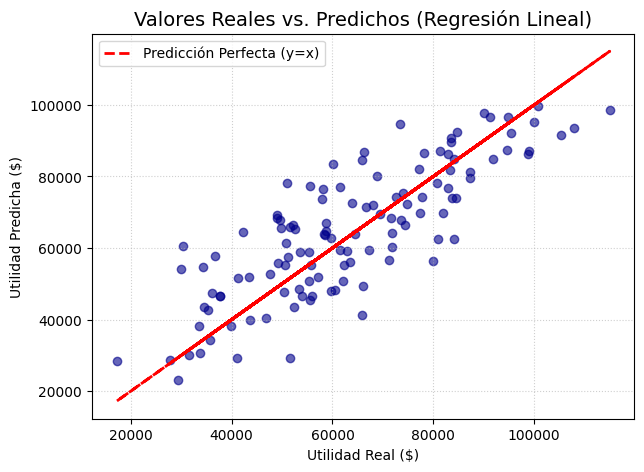

In [ ]:
# 1. Determinar cuál es el mejor modelo (mayor R²)
# La lógica compara el R² de la Regresión Lineal (pred_lr) contra el R² del Árbol (pred_tr)
if r2_score(yr_test, pred_lr) >= r2_score(yr_test, pred_tr):
    mejor_pred = pred_lr
    nombre_modelo = 'Regresión Lineal'
else:
    mejor_pred = pred_tr
    nombre_modelo = 'Árbol de Regresión'

# 2. Crear la gráfica
plt.figure(figsize=(7, 5))
plt.scatter(yr_test, mejor_pred, alpha=0.6, color='darkblue')

# 3. Añadir una línea diagonal (y=x) para referencia perfecta
plt.plot(yr_test, yr_test, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (y=x)')

plt.xlabel('Utilidad Real ($)')
plt.ylabel('Utilidad Predicha ($)')
plt.title(f'Valores Reales vs. Predichos ({nombre_modelo})', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 5) Conclusión final



El preprocesamiento de ambos datasets se centró en la gestión de valores faltantes (imputación con la mediana o moda) y la codificación de variables categóricas (nivel_educativo) mediante One-Hot Encoding. En el modelo de regresión, se añadió un escalamiento (StandardScaler) a todas las predictoras para homogenizar sus rangos (ventas, gastos, clientes), lo cual es crucial para el buen desempeño de la Regresión Lineal.



El Árbol de Decisión para clasificación (compro) arrojó un Accuracy del 82.5%. Sin embargo, la Matriz de Confusión reveló un sesgo significativo hacia la predicción de la clase positiva (Compra), fallando en identificar correctamente a la mayoría de los clientes que no compraron (solo 4 VN vs. 25 FP). El modelo tiene un alto riesgo de clasificar a un no-comprador como comprador.



Respecto a la regresión, es necesario comparar el $R^2$ de ambos modelos. Generalmente, la Regresión Lineal funciona mejor en este tipo de datos generados sintéticamente con relaciones lineales claras. El Árbol de Regresión, aunque es simple y robusto, podría no ser capaz de modelar con precisión la complejidad lineal del sistema con solo una profundidad de 5.



Recomendación Simple para SmartRetail: Se recomienda enfocarse en la fidelización y retención de clientes, ya que el modelo tiene dificultades para predecir qué clientes no comprarán. Una intervención dirigida a los clientes propensos a irse, identificados de forma incorrecta como compradores, podría ser una estrategia efectiva para mejorar la utilidad.